## Libraries, import data, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import CSV data
df = pd.read_csv('A_transcibed_sequences_2400-80-avg2.csv')

# Display the first few rows of the dataframe
df.head(10)

,Sequence,Signal Type,Time (s),Frequency (Hz),Correlation Value
0,0,D,9.59,7576,0.81
1,0,A,11.64,6820,1.00
2,0,B,14.94,6760,1.00
3,0,D,16.39,7616,0.79
4,0,C,18.67,6840,1.01
5,0,D,20.13,7496,0.88
6,0,A,22.38,6720,0.99
7,0,F,25.69,10038,0.72
8,0,E,26.83,7536,0.59
9,0,F,28.38,10018,0.77


## Sequence lengths (not counting EOL)

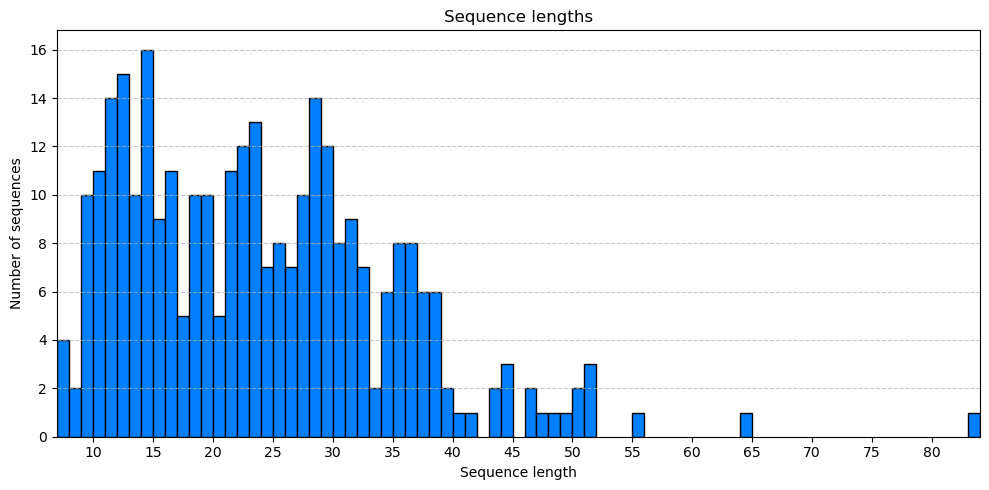

In [2]:
# Count signals
sequence_lengths = df.groupby('Sequence')['Signal Type'].count() - 1

# Count how many sequences fall into each length
length_counts = sequence_lengths.value_counts().sort_index()

# Plot as a histogram-style bar chart with no space between bars
plt.figure(figsize=(10, 5))
plt.bar(length_counts.index, length_counts.values, color="#0080ff", edgecolor='black', width=1, align='edge')

plt.title('Sequence lengths')
plt.xlabel('Sequence length')
plt.ylabel('Number of sequences')

min_len = length_counts.index.min()
max_len = length_counts.index.max()
plt.xlim(min_len, max_len + 1)
plt.xticks([x for x in range(min_len, max_len + 1) if x % 5 == 0])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Print sequences based on the Rule of 7

In [3]:
colors = {
    'blue': '\033[94m',
    'green': '\033[92m',
    'red': '\033[91m',
    'black': '\033[0m'  # resets to default
}

# Iterate through each sequence and print the Signal Types
for sequence_value, group in df.groupby('Sequence'):
    seen_letters = set()
    color_state = 'blue'
    transition_count = 0

    print(f"{sequence_value}:", end=' ')
    
    for signal in group['Signal Type']:
        # Always print 'X' in black
        if signal == 'X':
            print(f"{colors['black']}{signal}", end=' ')
            continue

        # Determine current color before updating seen_letters
        current_color = colors[color_state]
        print(f"{current_color}{signal}", end=' ')

        # Update seen_letters
        if signal in 'ABCDEFG':
            seen_letters.add(signal)

            # Check if adding this letter completes the full A–G set
            if len(seen_letters) == 7:
                transition_count += 1
                if transition_count == 1:
                    color_state = 'green'
                elif transition_count == 2:
                    color_state = 'red'
                elif transition_count >= 3:
                    color_state = 'black'
                seen_letters.clear()  # reset after completing set

    # Reset color after line
    print(colors['black'])  # new line and reset color

0: D A B D C D A F E F C A G B G C D G E F C E F E F E F E C G E B F G B E C A X 
1: D A B C E A E C A E D F B E F C E D A D A C G X 
2: F G C G F G E A B E A D G E B A E B C G F D X 
3: E A B E G C B F B E F D E C A B F G F B A C D X 
4: G E D G B F A F C F A D F G B E A D E A D E C X 
5: F C E G B E G F B G E C F E B F G D E B G F C D A D C D G E B D B G E F C A X 
6: B E B E D F C D F E G E F C D E B E B F D G B E G D G C E D A G B A C G C G A F B C B G A D F C F D B C B F D B G B A G B D F E X 
7: A F A G E D A D A E A C B X 
8: D C A F B G D C D F A C B D C B G B C E C G A E G B G F B F G B F C F G D X 
9: A F G F A E B C E G D G D C A D C D G D A G A C E B E F X 
10: A E G A C B D B C G A D C B D B D E G F X 
11: A B C F G A B A F B A B G B E D X 
12: D G A E D B F A B D E A B A E B G D B D C F E A E B A G C F B E C E F D X 
13: C B G C E D G D C D G B F C B F G E F A B A F D C E A G X 
14: D B G C F C G A G C B F A G A E B A F G F D B A G A E F D A F E F G A C X 
15: D B C G B G

## Number of subsequences

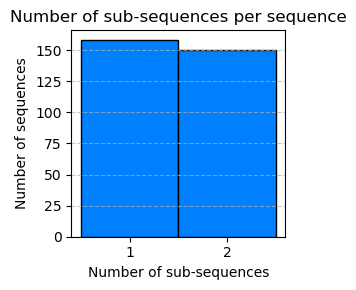

In [4]:
# List to hold the count of sub-sequences for each sequence
sub_sequence_counts = []

# Iterate through each sequence
for sequence_value, group in df.groupby('Sequence'):
    seen_letters = set()
    sub_sequence_count = 0

    # Iterate through the Signal Type in the sequence
    for signal in group['Signal Type']:
        # If it's one of the letters A–G, track it
        if signal in 'ABCDEFG':
            seen_letters.add(signal)
        
        # Once all 7 letters are seen, increment the sub-sequence count
        if len(seen_letters) == 7:
            sub_sequence_count += 1
            seen_letters.clear()  # Reset after completing a sub-sequence
    
    # Store the count of sub-sequences for the current sequence
    sub_sequence_counts.append(sub_sequence_count)

# Plot histogram of sub-sequence counts
plt.figure(figsize=(3, 3))
plt.hist(sub_sequence_counts, bins=range(min(sub_sequence_counts), max(sub_sequence_counts) + 2), edgecolor='black', color="#0080ff", align='left')

plt.title('Number of sub-sequences per sequence')
plt.xlabel('Number of sub-sequences')
plt.ylabel('Number of sequences')
plt.xticks(range(min(sub_sequence_counts), max(sub_sequence_counts) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

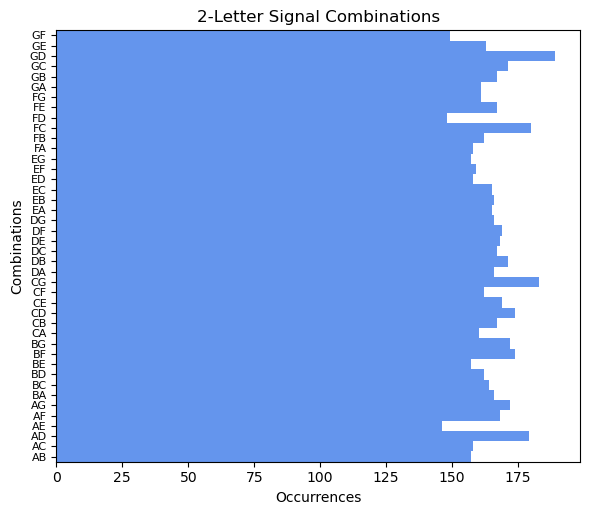

In [22]:
from itertools import product

# Assuming df is already defined and contains your data
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
all_combinations = [''.join(p) for p in product(letters, repeat=2)]
pair_counts = {pair: 0 for pair in all_combinations}

# Full 'Signal Type' sequence (in order)
signal_types = df['Signal Type'].tolist()
pairs = [signal_types[i] + signal_types[i+1] for i in range(len(signal_types) - 1)]

# Count valid pairs
for pair in pairs:
    if pair in pair_counts:
        pair_counts[pair] += 1

# Filter out zero-count combinations
filtered_counts = {k: v for k, v in pair_counts.items() if v > 0}

# Prepare data
labels = list(filtered_counts.keys())
values = list(filtered_counts.values())
num_labels = len(labels)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(6, num_labels/8))  # Tight height: 1 inch per bar
y_positions = list(range(num_labels))

# Bars: height = 1, no space between
ax.barh(y_positions, values, color='cornflowerblue', height=1.0)

# Y-axis labels with smaller font
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=8)
#ax.invert_yaxis()

# Tightly set y-axis limits (no gaps above or below bars)
ax.set_ylim(-0.5, num_labels - 0.5)

# Axis labels and title
ax.set_xlabel('Occurrences')
ax.set_ylabel('Combinations')
ax.set_title('2-Letter Signal Combinations')

plt.tight_layout()
plt.show()

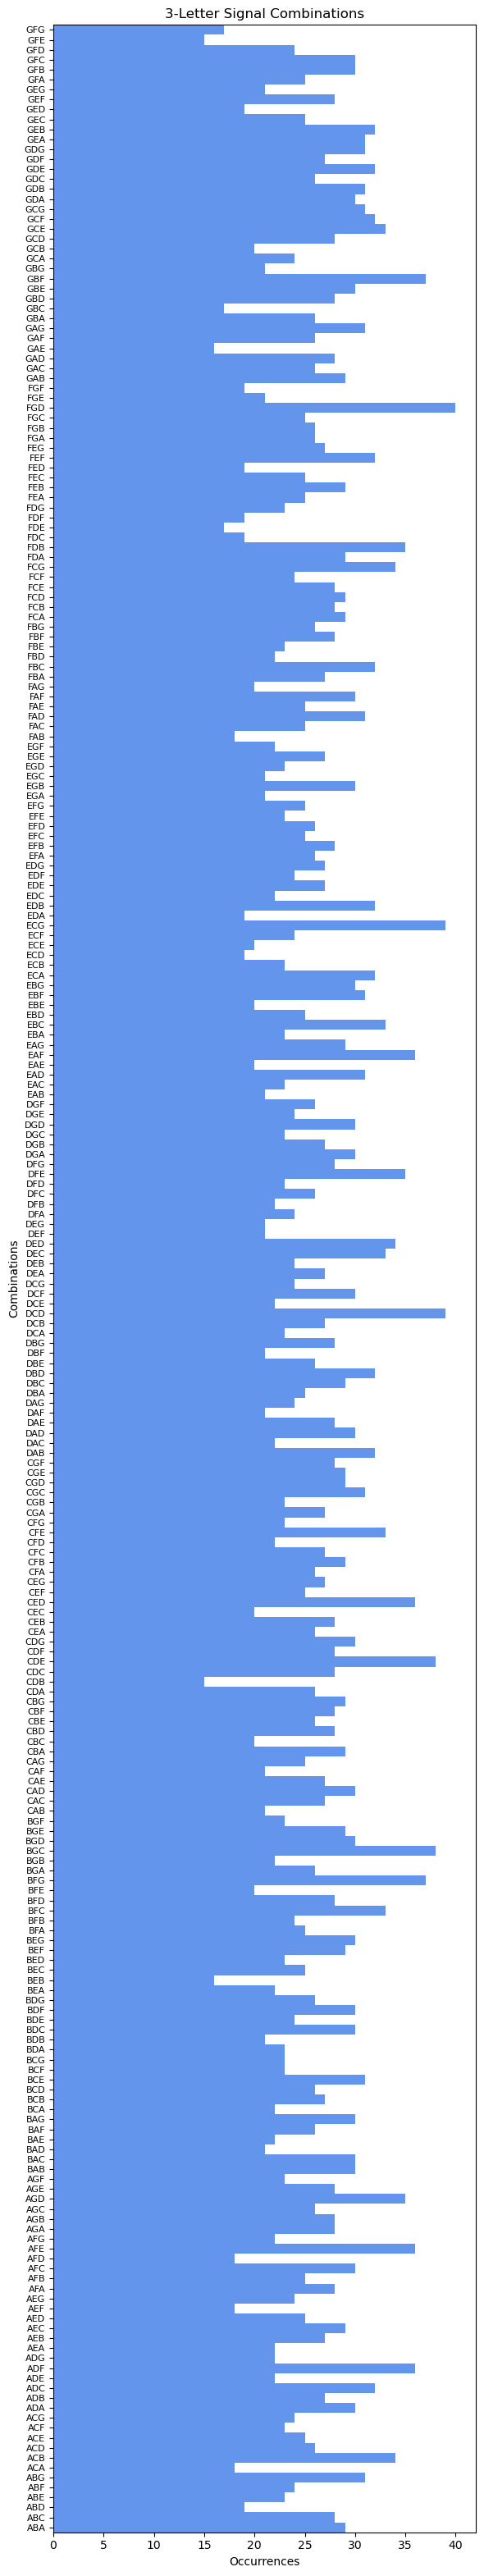

In [24]:
# Assuming df is already defined and contains your data
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
all_combinations = [''.join(p) for p in product(letters, repeat=3)]
pair_counts = {pair: 0 for pair in all_combinations}

# Full 'Signal Type' sequence (in order)
signal_types = df['Signal Type'].tolist()
pairs = [signal_types[i] + signal_types[i+1] + signal_types[i+2] for i in range(len(signal_types) - 2)]

# Count valid pairs
for pair in pairs:
    if pair in pair_counts:
        pair_counts[pair] += 1

# Filter out zero-count combinations
filtered_counts = {k: v for k, v in pair_counts.items() if v > 0}

# Prepare data
labels = list(filtered_counts.keys())
values = list(filtered_counts.values())
num_labels = len(labels)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(6, num_labels/8))  # Tight height: 1 inch per bar
y_positions = list(range(num_labels))

# Bars: height = 1, no space between
ax.barh(y_positions, values, color='cornflowerblue', height=1.0)

# Y-axis labels with smaller font
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=8)
#ax.invert_yaxis()

# Tightly set y-axis limits (no gaps above or below bars)
ax.set_ylim(-0.5, num_labels - 0.5)

# Axis labels and title
ax.set_xlabel('Occurrences')
ax.set_ylabel('Combinations')
ax.set_title('3-Letter Signal Combinations')

plt.tight_layout()
plt.show()

In [ ]:
# Mapping A-G -> 0-6
char_to_num = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}

# Group by unique Sequence values
result = {}

for seq in df['Sequence'].unique():
    group = df[df['Sequence'] == seq]['Signal Type']
    
    # Filter and convert
    numeric_values = [char_to_num[ch] for ch in group if ch in char_to_num]
    
    # Convert to base-2 string, assuming base-7 digits
    binary_values = [format(num, '03b') for num in numeric_values]  # 3-bit binary to cover 0–6
    result[seq] = binary_values

# Print results
for seq, binaries in result.items():
    print(f"Sequence {seq}: {' '.join(binaries)}")